In [62]:
# Useful starting lines
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
#%load_ext autoreload
#%autoreload 2

In [63]:
# Check the Python version
import sys
if sys.version.startswith("3."):
  print("You are running Python 3. Good job :)")
else:
  print("This notebook requires Python 3.\nIf you are using Google Colab, go to Runtime > Change runtime type and choose Python 3.")

You are running Python 3. Good job :)


In [64]:
try:
  import google.colab
  IN_COLAB = True
except:
  IN_COLAB = False
if IN_COLAB:
  # Clone the entire repo to access the files.
  !git clone -l -s https://github.com/epfml/OptML_course.git cloned-repo
  %cd cloned-repo/labs/ex02/template/

Cloning into 'cloned-repo'...
remote: Enumerating objects: 2952, done.
remote: Counting objects: 100% (393/393), done.
remote: Compressing objects: 100% (158/158), done.
remote: Total 2952 (delta 276), reused 305 (delta 232), pack-reused 2559 (from 2)
Receiving objects: 100% (2952/2952), 433.77 MiB | 45.38 MiB/s, done.
Resolving deltas: 100% (1552/1552), done.
/content/cloned-repo/labs/ex02/template/cloned-repo/labs/ex02/template/cloned-repo/labs/ex02/template


# Load the data

In [65]:
import datetime
from helpers import *

height, weight, gender = load_data(sub_sample=False, add_outlier=False)
x, mean_x, std_x = standardize(height)
b, A = build_model_data(x, weight)

In [66]:
print('Number of samples n = ', b.shape[0])
print('Dimension of each sample d = ', A.shape[1])

Number of samples n =  10000
Dimension of each sample d =  2


# Least Squares Estimation
Least squares estimation is one of the fundamental machine learning algorithms. Given an $ n \times d $ matrix $A$ and a $ n \times 1$ vector $b$, the goal is to find a vector $x \in \mathbb{R}^d$ which minimizes the objective function $$f(x) = \frac{1}{2n} \sum_{i=1}^{n} (a_i^\top x - b_i)^2 = \frac{1}{2n} \|Ax - b\|^2 $$

In this exercise, we will try to fit $x$ using Least Squares Estimation.

One can see the function is $L$ smooth with $L =\frac1n\|A^T A\|  = \frac1n\|A\|^2$ (Lemma 2.3 for the first equality, and a few manipulations for the second).

# Computing the Objective Function
Fill in the `calculate_objective` function below:

In [67]:
def calculate_objective(Axmb):
    """Calculate the mean squared error for vector Axmb = Ax - b."""
    return np.dot(Axmb, Axmb) / (2 * Axmb.shape[0])

# Compute smoothness constant $L$

To compute the spectral norm of A you can use np.linalg.norm(A, 2)

In [68]:
def calculate_L(b, A):
    """Calculate the smoothness constant for f"""
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute ||A.T*A||
    # ***************************************************
    temp = np.linalg.norm(A.T@A, 2)
    # ***************************************************
    L = temp / b.shape[0]
    # ***************************************************
    return L

# Gradient Descent

Please fill in the functions `compute_gradient` below:

In [69]:
def compute_gradient(b, A, x):
    """Compute the gradient."""
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute gradient and objective
    Axmb = A @ x - b
    grad = (A.T @ A @ x - A.T @ b) / b.shape[0]
    # ***************************************************
    return grad, Axmb

Please fill in the functions `gradient_descent` below:

In [76]:
def gradient_descent(b, A, initial_x, max_iters, gamma):
    """Gradient descent algorithm."""
    # Define parameters to store x and objective func. values
    xs = [initial_x]
    objectives = []
    x = initial_x
    for n_iter in range(max_iters):
        # ***************************************************
        grad, Axmb = compute_gradient(b, A, x)
        obj = calculate_objective(Axmb)
        # ***************************************************
        x = x - gamma * grad
        # ***************************************************
        # store x and objective function value
        xs.append(x)
        objectives.append(obj)
        print("Gradient Descent({bi}/{ti}): objective={l}".format(
              bi=n_iter, ti=max_iters - 1, l=obj))

    return objectives, xs

Test your gradient descent function with a naive step size through gradient descent demo shown below:

In [77]:
# from gradient_descent import *
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 50

gamma = 0.1

# Initialization
x_initial = np.zeros(A.shape[1])

# Start gradient descent.
start_time = datetime.datetime.now()
gradient_objectives_naive, gradient_xs_naive = gradient_descent(b, A, x_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("Gradient Descent: execution time={t:.3f} seconds".format(t=exection_time))

Gradient Descent(0/49): objective=2792.236712759168
Gradient Descent(1/49): objective=2264.635056030006
Gradient Descent(2/49): objective=1837.2777140793844
Gradient Descent(3/49): objective=1491.1182670993812
Gradient Descent(4/49): objective=1210.7291150455787
Gradient Descent(5/49): objective=983.6139018819974
Gradient Descent(6/49): objective=799.6505792194974
Gradient Descent(7/49): objective=650.6402878628719
Gradient Descent(8/49): objective=529.9419518640047
Gradient Descent(9/49): objective=432.1762997049227
Gradient Descent(10/49): objective=352.98612145606586
Gradient Descent(11/49): objective=288.8420770744917
Gradient Descent(12/49): objective=236.88540112541668
Gradient Descent(13/49): objective=194.80049360666587
Gradient Descent(14/49): objective=160.71171851647756
Gradient Descent(15/49): objective=133.09981069342504
Gradient Descent(16/49): objective=110.7341653567523
Gradient Descent(17/49): objective=92.61799263404743
Gradient Descent(18/49): objective=77.9438927286

Time Visualization

In [78]:
from ipywidgets import IntSlider, interact
from grid_search import *

print(gradient_xs_naive)

def plot_figure(n_iter):
    # Generate grid data for visualization (parameters to be swept and best combination)
    grid_x0, grid_x1 = generate_w(num_intervals=10)
    grid_objectives = grid_search(b, A, grid_x0, grid_x1)
    obj_star, x0_star, x1_star = get_best_parameters(grid_x0, grid_x1, grid_objectives)

    fig = gradient_descent_visualization(
        gradient_objectives_naive, gradient_xs_naive, grid_objectives, grid_x0, grid_x1, mean_x, std_x, height, weight, n_iter)
    fig.set_size_inches(10.0, 6.0)

interact(plot_figure, n_iter=IntSlider(min=1, max=len(gradient_xs_naive)))

[array([0., 0.]), array([7.3293922 , 1.34797124]), array([13.92584518,  2.56114536]), array([19.86265286,  3.65300207]), array([25.20577978,  4.63567311]), array([30.014594  ,  5.52007704]), array([34.3425268 ,  6.31604058]), array([38.23766632,  7.03240776]), array([41.74329189,  7.67713823]), array([44.8983549 ,  8.25739565]), array([47.73791161,  8.77962733]), array([50.29351265,  9.24963584]), array([52.59355358,  9.6726435 ]), array([54.66359043, 10.05335039]), array([56.52662358, 10.3959866 ]), array([58.20335343, 10.70435918]), array([59.71241028, 10.98189451]), array([61.07056146, 11.2316763 ]), array([62.29289751, 11.45647991]), array([63.39299996, 11.65880317]), array([64.38309216, 11.84089409]), array([65.27417515, 12.00477593]), array([66.07614983, 12.15226958]), array([66.79792705, 12.28501386]), array([67.44752654, 12.40448372]), array([68.03216609, 12.51200659]), array([68.55834168, 12.60877718]), array([69.03189971, 12.6958707 ]), array([69.45810194, 12.77425488]), arra

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

Try doing gradient descent with a better learning rate

In [79]:
# Define the parameters of the algorithm.
max_iters = 50

# ***************************************************
# INSERT YOUR CODE HERE
# TODO: a better learning rate using the smoothness of f
# ***************************************************
gamma = 1/calculate_L(b, A)

# Initialization
x_initial = np.zeros(A.shape[1])

# Start gradient descent.
start_time = datetime.datetime.now()
gradient_objectives, gradient_xs = gradient_descent(b, A, x_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("Gradient Descent: execution time={t:.3f} seconds".format(t=exection_time))

Gradient Descent(0/49): objective=2792.236712759168
Gradient Descent(1/49): objective=15.3858878688294
Gradient Descent(2/49): objective=15.385887868829398
Gradient Descent(3/49): objective=15.385887868829398
Gradient Descent(4/49): objective=15.385887868829398
Gradient Descent(5/49): objective=15.385887868829398
Gradient Descent(6/49): objective=15.385887868829398
Gradient Descent(7/49): objective=15.385887868829398
Gradient Descent(8/49): objective=15.385887868829398
Gradient Descent(9/49): objective=15.385887868829398
Gradient Descent(10/49): objective=15.385887868829398
Gradient Descent(11/49): objective=15.385887868829398
Gradient Descent(12/49): objective=15.385887868829398
Gradient Descent(13/49): objective=15.385887868829398
Gradient Descent(14/49): objective=15.385887868829398
Gradient Descent(15/49): objective=15.385887868829398
Gradient Descent(16/49): objective=15.385887868829398
Gradient Descent(17/49): objective=15.385887868829398
Gradient Descent(18/49): objective=15.385

Time visualization with a better learning rate

In [80]:
def plot_figure(n_iter):
    # Generate grid data for visualization (parameters to be swept and best combination)
    grid_x0, grid_x1 = generate_w(num_intervals=10)
    grid_objectives = grid_search(b, A, grid_x0, grid_x1)
    obj_star, x0_star, x1_star = get_best_parameters(grid_x0, grid_x1, grid_objectives)

    fig = gradient_descent_visualization(
        gradient_objectives, gradient_xs, grid_objectives, grid_x0, grid_x1, mean_x, std_x, height, weight, n_iter)
    fig.set_size_inches(10.0, 6.0)

interact(plot_figure, n_iter=IntSlider(min=1, max=len(gradient_xs)))

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

# Loading more complex data
The data is taken from https://archive.ics.uci.edu/ml/datasets/Concrete+Compressive+Strength

In [81]:
data = np.loadtxt("Concrete_Data.csv",delimiter=",")

A = data[:,:-1]
b = data[:,-1]
A, mean_A, std_A = standardize(A)

In [82]:
print('Number of samples n = ', b.shape[0])
print('Dimension of each sample d = ', A.shape[1])

Number of samples n =  1030
Dimension of each sample d =  8


# Running gradient descent

## Assuming bounded gradients
Assume we are moving in a bounded region $\|x\| \leq 25$ containing all iterates (and we assume $\|x-x^\star\| \leq 25$ as well, for simplicity). Then by $\nabla f(x) = \frac{1}{n}A^\top (Ax - b)$, one can see that $f$ is Lipschitz over that bounded region, with Lipschitz constant $\|\nabla f(x)\| \leq \frac{1}{n} (\|A^\top A\|\|x\| + \|A^\top b\|)$

In [85]:
# ***************************************************
# INSERT YOUR CODE HERE
# TODO: Compute the bound on the gradient norm
# ***************************************************
grad_norm_bound = (1 / b.shape[0]) * (np.linalg.norm(A.T@A, 2)* np.linalg.norm(x, 2) + np.linalg.norm(A.T@b, 2))


Fill in the learning rate assuming bounded gradients

In [86]:
max_iters = 50

# ***************************************************
# INSERT YOUR CODE HERE
# TODO: Compute learning rate based on bounded gradient
# ***************************************************
gamma = 25 / (grad_norm_bound * np.sqrt(50))


# Initialization
x_initial = np.zeros(A.shape[1])

# Start gradient descent.
start_time = datetime.datetime.now()
bd_gradient_objectives, bd_gradient_xs = gradient_descent(b, A, x_initial, max_iters, gamma)
end_time = datetime.datetime.now()


# Print result
exection_time = (end_time - start_time).total_seconds()
print("Gradient Descent: execution time={t:.3f} seconds".format(t=exection_time))

# Averaging the iterates as is the case for bounded gradients case
bd_gradient_objectives_averaged = []
for i in range(len(bd_gradient_xs)):
    if i > 0:
        bd_gradient_xs[i] = (i * bd_gradient_xs[i-1] + bd_gradient_xs[i])/(i + 1)
    grad, err = compute_gradient(b, A, bd_gradient_xs[i])
    obj = calculate_objective(err)
    bd_gradient_objectives_averaged.append(obj)

Gradient Descent(0/49): objective=780.8686016504854
Gradient Descent(1/49): objective=778.2052535582222
Gradient Descent(2/49): objective=775.6343998725025
Gradient Descent(3/49): objective=773.1526740682194
Gradient Descent(4/49): objective=770.7568365067913
Gradient Descent(5/49): objective=768.4437694987688
Gradient Descent(6/49): objective=766.2104725651755
Gradient Descent(7/49): objective=764.0540578892663
Gradient Descent(8/49): objective=761.9717459507343
Gradient Descent(9/49): objective=759.9608613347534
Gradient Descent(10/49): objective=758.0188287085846
Gradient Descent(11/49): objective=756.1431689587774
Gradient Descent(12/49): objective=754.3314954823138
Gradient Descent(13/49): objective=752.5815106253243
Gradient Descent(14/49): objective=750.8910022632876
Gradient Descent(15/49): objective=749.2578405168784
Gradient Descent(16/49): objective=747.679974597893
Gradient Descent(17/49): objective=746.1554297799102
Gradient Descent(18/49): objective=744.6823044885805
Grad

## Gradient descent using smoothness
Fill in the learning rate using smoothness of the function

In [87]:
max_iters = 50


# ***************************************************
# INSERT YOUR CODE HERE
# TODO: a better learning rate using the smoothness of f
# ***************************************************
gamma = 1 / calculate_L(b, A)

# Initialization
x_initial = np.zeros(A.shape[1])

# Start gradient descent.
start_time = datetime.datetime.now()
gradient_objectives, gradient_xs = gradient_descent(b, A, x_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("Gradient Descent: execution time={t:.3f} seconds".format(t=exection_time))

Gradient Descent(0/49): objective=780.8686016504854
Gradient Descent(1/49): objective=721.5052560260676
Gradient Descent(2/49): objective=706.7843584315376
Gradient Descent(3/49): objective=702.1659603718192
Gradient Descent(4/49): objective=700.3195706210597
Gradient Descent(5/49): objective=699.3927282552013
Gradient Descent(6/49): objective=698.8265138747602
Gradient Descent(7/49): objective=698.4252460378511
Gradient Descent(8/49): objective=698.1121802865196
Gradient Descent(9/49): objective=697.8540419775696
Gradient Descent(10/49): objective=697.6346924802036
Gradient Descent(11/49): objective=697.4451956987402
Gradient Descent(12/49): objective=697.2798771098778
Gradient Descent(13/49): objective=697.1346943450259
Gradient Descent(14/49): objective=697.0065306304227
Gradient Descent(15/49): objective=696.892866936634
Gradient Descent(16/49): objective=696.7916143488982
Gradient Descent(17/49): objective=696.7010172175321
Gradient Descent(18/49): objective=696.6195897256094
Grad

## Plotting the Evolution of the Objective Function

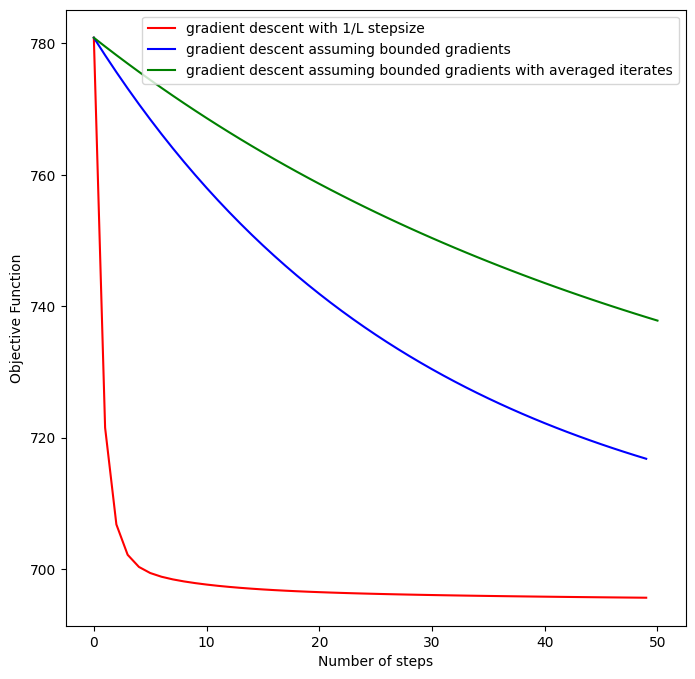

In [88]:
plt.figure(figsize=(8, 8))
plt.xlabel('Number of steps')
plt.ylabel('Objective Function')
#plt.yscale("log")
plt.plot(range(len(gradient_objectives)), gradient_objectives,'r', label='gradient descent with 1/L stepsize')
plt.plot(range(len(bd_gradient_objectives)), bd_gradient_objectives,'b', label='gradient descent assuming bounded gradients')
plt.plot(range(len(bd_gradient_objectives_averaged)), bd_gradient_objectives_averaged,'g', label='gradient descent assuming bounded gradients with averaged iterates')
plt.legend(loc='upper right')
plt.show()